<a href="https://colab.research.google.com/github/sayali-jatrate/project1/blob/main/encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
upload =files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
import pandas as pd
df_model = pd.read_csv('Iris.csv')
df = pd.read_csv('Iris.csv').drop(columns=['Id'])

# Clean label names for readability
df['Species'] = df['Species'].str.replace('Iris-', '', regex=False)

print('Shape:', df.shape)
print('\nClass distribution:')
print(df['Species'].value_counts())
df.head(8)

Shape: (150, 5)

Class distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


In [ ]:
df = pd.read_csv('Iris.csv').drop(columns=['Id'])

# Clean label names for readability
df['Species'] = df['Species'].str.replace('Iris-', '', regex=False)

print('Shape:', df.shape)
print('\nClass distribution:')
print(df['Species'].value_counts())
df.head(8)


Shape: (150, 5)

Class distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder=LabelEncoder()
encoded_petallength=label_encoder.fit_transform(df_model['Species'])

for namer, code in zip(label_encoder.classes_,range(len(label_encoder.classes_))):
  print(f'{namer:20s}->{code}')

Iris-setosa         ->0
Iris-versicolor     ->1
Iris-virginica      ->2


In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
species_ohe=ohe.fit_transform(df_model[['Species']])
ohe_cols=ohe.get_feature_names_out(['Species'])

df_ohe=pd.DataFrame(species_ohe,columns=ohe_cols)
print(f'OneHot Encoded (first 8 rows):')
print(pd.concat([df_model['Species'].head(8).reset_index(drop=True),df_ohe.head(8)],axis=1).to_string())

OneHot Encoded (first 8 rows):
       Species  Species_Iris-setosa  Species_Iris-versicolor  Species_Iris-virginica
0  Iris-setosa                  1.0                      0.0                     0.0
1  Iris-setosa                  1.0                      0.0                     0.0
2  Iris-setosa                  1.0                      0.0                     0.0
3  Iris-setosa                  1.0                      0.0                     0.0
4  Iris-setosa                  1.0                      0.0                     0.0
5  Iris-setosa                  1.0                      0.0                     0.0
6  Iris-setosa                  1.0                      0.0                     0.0
7  Iris-setosa                  1.0                      0.0                     0.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_model[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df_model['PetalLengthCm'] # Assuming PetalLengthCm as the target for this simple regression example

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

x_simple_train=X_train[['SepalLengthCm']]
x_simple_test=X_test[['SepalLengthCm']]

lr_simple=LinearRegression()
lr_simple.fit(x_simple_train,y_train)

y_pred_simple=lr_simple.predict(x_simple_test)

print('Simple Linear Regression')
print(f'Intercept(β0): {lr_simple.intercept_:.4f}')
print(f'Coefficient(β1): {lr_simple.coef_[0]:.4f}')
print(f'-> Equation:PetalLength={lr_simple.intercept_:.2f}+{lr_simple.coef_[0]:.2f}*SepalLengthCm')

Simple Linear Regression
Intercept(β0): -6.5832
Coefficient(β1): 1.7893
-> Equation:PetalLength=-6.58+1.79*SepalLengthCm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


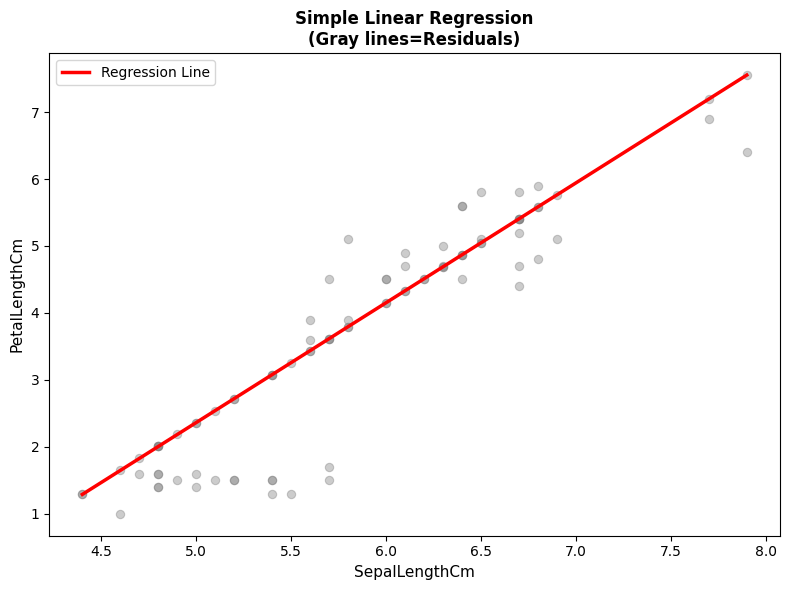

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

x_line=np.linspace(X_test['SepalLengthCm'].min(),X_test['SepalLengthCm'].max(),100).reshape(-1,1)

y_line=lr_simple.predict(x_line)
ax.plot(x_line,y_line,color='red',linewidth=2.5,label='Regression Line')

for i,(xi,yi,yp) in enumerate(zip(X_test['SepalLengthCm'],y_test,y_pred_simple)):
  ax.scatter([xi,xi],[yi,yp],color='grey',alpha=0.4,linewidth=0.8)

ax.set_xlabel('SepalLengthCm',fontsize=11)
ax.set_ylabel('PetalLengthCm',fontsize=11)
ax.set_title('Simple Linear Regression\n(Gray lines=Residuals)',fontsize=12,fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_train_sm = sm.add_constant(x_train_scaled)
ols_model = sm.OLS(y_train, x_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          PetalLengthCm   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.873e+31
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:46:18   Log-Likelihood:                 3444.1
No. Observations:                 105   AIC:                            -6878.
Df Residuals:                     100   BIC:                            -6865.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8714   1.38e-16   2.82e+16      0.0

In [ ]:
import statsmodels.api as sm
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

x_vif=sm.add_constant(X_train)
vif_data=pd.DataFrame()
vif_data['features']=x_vif.columns
vif_data['VIF']=[variance_inflation_factor(x_vif.values,i)for i in range(x_vif.shape[1])]
print('Variance Inflation Factor(VIF)')
print(vif_data.to_string(index=False))

Variance Inflation Factor(VIF)
     features        VIF
        const 122.404189
SepalLengthCm   7.083604
 SepalWidthCm   1.963822
PetalLengthCm  30.771850
 PetalWidthCm  15.423373


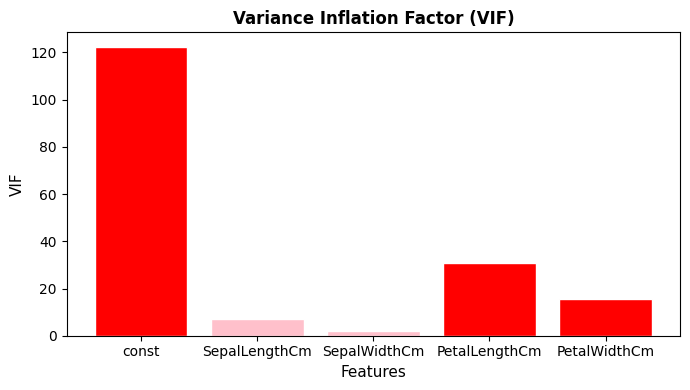

In [ ]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots(figsize=(7,4))
colors_vif = ['red' if v>10 else 'green' if v>10 else 'pink' for v in vif_data['VIF']]
bars=ax.bar(vif_data['features'],vif_data['VIF'],color=colors_vif,edgecolor='white')
ax.set_xlabel('Features',fontsize=11)
ax.set_ylabel('VIF',fontsize=11)
ax.set_title('Variance Inflation Factor (VIF)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X=df_model[['SepalLengthCm','SepalWidthCm','PetalWidthCm']]
y=df_model['PetalLengthCm']

x_train,x_test,y_train,y_test = train_test_split(
    X,y,test_size=0.25,random_state=42
)

print("Iris shape",x_train.shape)
print("test shape",x_test.shape)

Iris shape (112, 3)
test shape (38, 3)


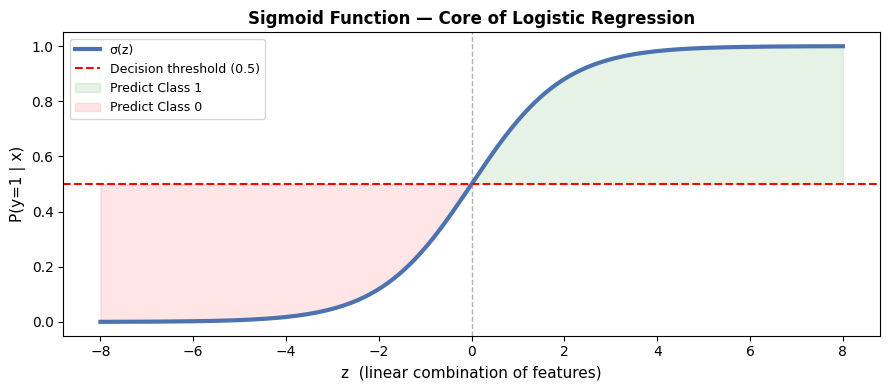

In [ ]:
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(z, sigmoid, color='#4C72B0', linewidth=3, label='σ(z)')
ax.axhline(0.5, color='red',   linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
ax.axvline(0.0, color='gray',  linestyle='--', linewidth=1,   alpha=0.6)
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.10, color='green', label='Predict Class 1')
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.10, color='red',   label='Predict Class 0')
ax.set_xlabel('z  (linear combination of features)', fontsize=11)
ax.set_ylabel('P(y=1 | x)', fontsize=11)
ax.set_title('Sigmoid Function — Core of Logistic Regression', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier

SEED = 42
SPEED = 42 # Assuming SPEED is intended for random_state as well, or another seed value.

X_tr_sc, X_te_sc, y_tr, y_te = (
    X_train_sc, X_test_sc, y_bin_train, y_bin_test)

# X_tr_raw and X_te_raw seem to be intended for raw features, but Xc_tr/Xc_te are not defined.
# If you need raw features, you should use x_train and x_test from cell 'opaPWJ0BD8l3'.
# For now, I will comment these out or use x_train/x_test if appropriate.
# Let's assume you meant the original unscaled x_train and x_test.
X_tr_raw = x_train.values # Using x_train from previous cells
X_te_raw = x_test.values   # Using x_test from previous cells

dt_full = DecisionTreeClassifier(random_state=SEED)
dt_full.fit(X_tr_sc, y_tr)

dt_pruned = DecisionTreeClassifier(random_state=SPEED)
dt_pruned.fit(X_tr_sc, y_tr)

print('Decision Tree(full depth)')

Decision Tree(full depth)


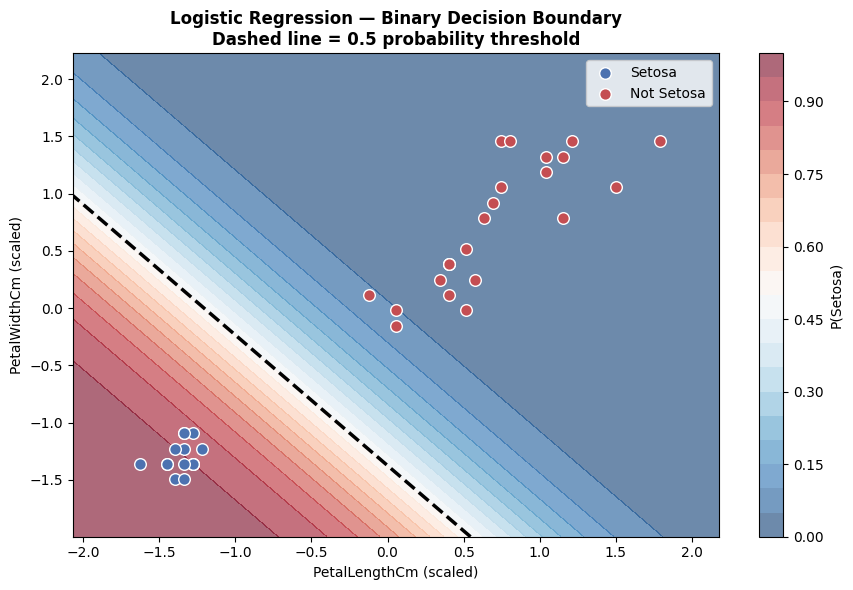

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# --- Code brought in from previous cells to define dependencies ---
# Load Iris dataset directly from sklearn to avoid FileNotFoundError
iris = load_iris()
df_model = pd.DataFrame(data=iris.data, columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])
df_model['Species'] = iris.target_names[iris.target]

# Define features (X_2D) and target (y_2D) specifically for the 2D visualization
X_2D = df_model[['PetalLengthCm', 'PetalWidthCm']]
y_2D = (df_model['Species'] == 'setosa').astype(int) # Binary target for setosa vs non-setosa

# Split data for 2D visualization
X_train_2D, X_test_2D, y_train_bin_2D, y_test_bin_2D = train_test_split(
    X_2D, y_2D, test_size=0.25, random_state=42
)
# -----------------------------------------------------------------

# Initialize StandardScaler
scaler_2D = StandardScaler() # Use a separate scaler for clarity

# Scale the training and test features for 2D visualization
X_train_sc_2D = scaler_2D.fit_transform(X_train_2D)
X_test_sc_2D = scaler_2D.transform(X_test_2D)

# ── Visualise binary decision boundary (2 features) ──────────────────────────
# Use PetalLength & PetalWidth for clearest boundary
X2_train = X_train_sc_2D
X2_test  = X_test_sc_2D

lr_2d = LogisticRegression(random_state=42)
lr_2d.fit(X2_train, y_train_bin_2D) # Fit with the correct binary target for 2D

xx, yy = np.meshgrid(
    np.linspace(X2_train[:, 0].min() - 0.5, X2_train[:, 0].max() + 0.5, 300),
    np.linspace(X2_train[:, 1].min() - 0.5, X2_train[:, 1].max() + 0.5, 300)
)
Z = lr_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.6)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.5, linestyles='--')
plt.colorbar(contour, ax=ax, label='P(Setosa)')

for label_val, color, name in [(1, '#4C72B0', 'Setosa'), (0, '#C44E52', 'Not Setosa')]:
    mask = y_test_bin_2D == label_val # Plot with the correct binary target for 2D test set
    ax.scatter(X2_test[mask, 0], X2_test[mask, 1],
               c=color, s=70, edgecolor='white', label=name, zorder=5)

ax.set_xlabel('PetalLengthCm (scaled)')
ax.set_ylabel('PetalWidthCm (scaled)')
ax.set_title('Logistic Regression — Binary Decision Boundary\n'
             'Dashed line = 0.5 probability threshold', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris # To ensure df_model is available

# --- Re-create df_model for self-contained cell ---
iris = load_iris()
df_model = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_model['species'] = iris.target_names[iris.target]

# --- Define features (X) and categorical target (y_clf) for classification ---
X_clf = df_model[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y_clf = df_model['species']

# --- Split data for classification ---
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf # Stratify for balanced classes
)

# --- Scale features for classification ---
scaler_clf = StandardScaler()
X_train_sc_clf = scaler_clf.fit_transform(X_train_clf)
X_test_sc_clf = scaler_clf.transform(X_test_clf)

# --- Encode categorical target labels ---
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_clf)
y_test_encoded = le.transform(y_test_clf)

lr_multi = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=500,
    C=1.0,               # C = 1/alpha (regularization strength)
    random_state=42
)

# Use the correctly prepared data for classification
lr_multi.fit(X_train_sc_clf, y_train_encoded)
y_pred_lr = lr_multi.predict(X_test_sc_clf)

print('Multiclass Logistic Regression (Softmax / Multinomial)')
print(f'  Accuracy: {accuracy_score(y_test_encoded, y_pred_lr):.4f}')
print('Classification Report:')
print(classification_report(y_test_encoded, y_pred_lr,
                             target_names=le.classes_))

Multiclass Logistic Regression (Softmax / Multinomial)
  Accuracy: 0.9211
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
